In [2]:
# 첫 번째 셀: 필요한 라이브러리 설치 (최초 1회)
!pip install ultralytics
!pip install opencv-python matplotlib
!pip install langchain chromadb
!pip install torch torchvision
!pip install -U langchain langchain-community langchain-chroma langchain-openai

  Attempting uninstall: click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.2 which is incompatible.



image 1/1 c:\Users\human-31\project\ydataprofiling\test_image.jpg: 480x640 (no detections), 141.8ms
Speed: 10.2ms preprocess, 141.8ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


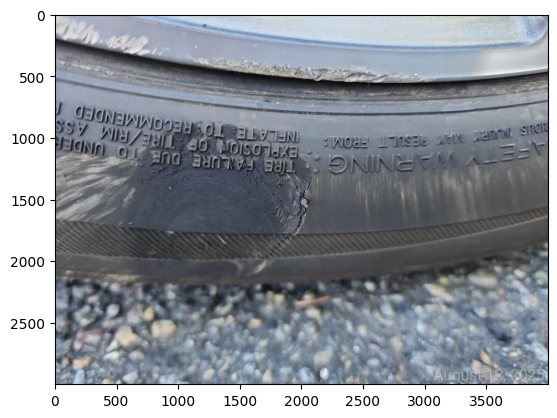

In [3]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

# 1. 모델 로드 (Pre-trained 모델 사용)
model = YOLO('yolov8n.pt') # 또는 직접 학습한 'best.pt'

# 2. 이미지 테스트 (동영상이나 웹캠 대신 일단 이미지 한 장으로 시작)
results = model('test_image.jpg')

# 3. 결과 시각화 (Bounding Box 확인)
res_plotted = results[0].plot()
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.show()

In [4]:
# 수정된 임포트 방식
from langchain_chroma import Chroma
from langchain_community.embeddings import DeterministicFakeEmbedding # 테스트용 가짜 임베딩
from langchain_text_splitters import CharacterTextSplitter

# 1. 설비 매뉴얼 데이터 (예시)
manual_text = """
설비 A의 표면에 스크래치가 발생하면 가동을 즉시 중단하십시오.
이후 세척액을 이용해 표면을 닦고 재검사하십시오.
"""

# 2. 텍스트 분할
text_splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=0)
texts = text_splitter.split_text(manual_text)

print(f"분할된 텍스트 개수: {len(texts)}")

c:\Users\human-31\project\ydataprofiling\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


분할된 텍스트 개수: 1


In [5]:
import os
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class MVTecDataset(Dataset):
    def __init__(self, root_path, category, transform=None, is_train=True):
        self.transform = transform
        self.mode = 'train' if is_train else 'test'
        self.data_path = os.path.join(root_path, category, self.mode)
        
        self.image_files = []
        for (root, dirs, files) in os.walk(self.data_path):
            for f in files:
                if f.endswith('.png'):
                    self.image_files.append(os.path.join(root, f))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# 설정
data_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 사용 예시 (bottle 카테고리)
train_dataset = MVTecDataset(root_path='./mvtec_anomaly_detection', category='bottle', transform=data_transform, is_train=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"학습 이미지 개수: {len(train_dataset)}")

학습 이미지 개수: 209


In [6]:
import torch
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn.functional as F

# 1. 사전 학습된 ResNet50 로드 (Feature Extractor 역할)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1).to(device)
model.eval()

# 중간 레이어의 특징을 추출하기 위한 Hook 설정
features = []
def hook(module, input, output):
    features.append(output)

# 중간 레이어(layer2, layer3)에 hook 등록 (PatchCore 방식)
model.layer2[-1].register_forward_hook(hook)
model.layer3[-1].register_forward_hook(hook)

In [8]:
import numpy as np

def embed_batch(data_loader):
    memory_bank = []
    with torch.no_grad():
        for i, imgs in enumerate(data_loader):
            imgs = imgs.to(device)
            features.clear()
            _ = model(imgs)
            
            # 각 레이어의 특징 추출
            # layer2: [batch, 512, 64, 64], layer3: [batch, 1024, 32, 32] (입력 256 기준)
            
            # 방법: 가장 간단하게 layer2만 사용하거나, 혹은 각각 flatten 해서 보관
            # 여기서는 우선 에러 해결을 위해 layer2(index 0)의 특징만 사용하여 로직을 완성합니다.
            target_feature = features[0] # layer2 추출
            
            # Spatial Pooling (주변 정보를 통합하여 강건함 확보)
            pooled_feat = F.avg_pool2d(target_feature, kernel_size=3, stride=1, padding=1)
            
            # [Batch, Channel, H, W] -> [Batch * H * W, Channel] 형태로 변환
            # 이 때 채널 수는 항상 512로 일정해집니다.
            f_flat = pooled_feat.permute(0, 2, 3, 1).reshape(-1, pooled_feat.shape[1])
            
            memory_bank.append(f_flat.cpu().numpy())
                
    return np.concatenate(memory_bank, axis=0)

# 실행
memory_bank = embed_batch(train_loader)
print(f"Memory Bank 구축 완료: {memory_bank.shape}") # (N, 512) 형태가 됩니다.

Memory Bank 구축 완료: (214016, 512)


In [9]:
from sklearn.neighbors import NearestNeighbors

# 1. KNN 알고리즘으로 가장 가까운 정상 특징 찾기 준비
nn_model = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', n_jobs=-1)
nn_model.fit(memory_bank)

def predict(test_img):
    # 테스트 이미지 특징 추출
    features.clear()
    with torch.no_grad():
        _ = model(test_img.to(device))
    
    # 특징 맵 처리 (Layer 2 기준 예시)
    test_feat = F.avg_pool2d(features[0], kernel_size=3, stride=1, padding=1)
    batch, c, h, w = test_feat.shape
    test_feat_flat = test_feat.permute(0, 2, 3, 1).reshape(-1, c).cpu().numpy()
    
    # 2. Anomaly Score 계산 (거리 측정)
    distances, _ = nn_model.kneighbors(test_feat_flat)
    
    # 3. Anomaly Map (Heatmap) 재구성
    anomaly_map = distances.reshape(h, w)
    anomaly_map = cv2.resize(anomaly_map, (256, 256)) # 원본 크기로 복원
    
    # 4. 최종 Anomaly Score (가장 큰 거리값)
    anomaly_score = np.max(anomaly_map)
    
    return anomaly_map, anomaly_score

# 결과 확인
# test_img = next(iter(test_loader))
# amap, score = predict(test_img)

테스트 이미지 로드 완료: 83장


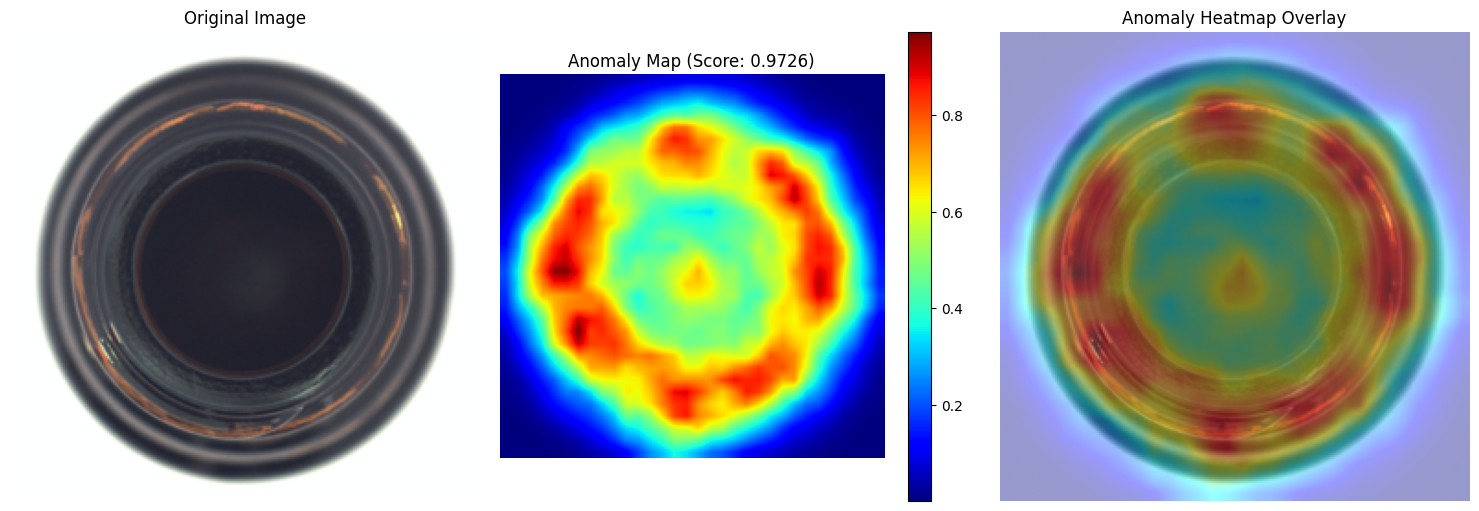

In [10]:
import matplotlib.pyplot as plt
import cv2
from sklearn.neighbors import NearestNeighbors

# 1. KNN 모델 다시 정의 (layer2 특징 크기 512에 맞춤)
nn_model = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', n_jobs=-1)
# (중요!) 이전 단계에서 생성한 memory_bank를 학습시킵니다.
nn_model.fit(memory_bank) 

def predict_and_visualize(test_loader):
    # 2. test_loader에서 이미지 한 장 가져오기 (배치 단위)
    # 이미지는 [Batch, Channel, H, W] 형태
    test_imgs = next(iter(test_loader)) 
    test_img = test_imgs[0:1] # 첫 번째 이미지 선택: [1, Channel, H, W]
    
    # 3. 테스트 이미지 특징 추출 (layer2 사용)
    features.clear()
    with torch.no_grad():
        _ = model(test_img.to(device))
    
    # layer2 특징 추출: [1, 512, 64, 64] (입력 256 기준)
    test_feat = features[0]
    batch, c, h, w = test_feat.shape
    
    # 4. Spatial Pooling (학습 때와 동일하게 주변 정보 통합)
    pooled_test_feat = F.avg_pool2d(test_feat, kernel_size=3, stride=1, padding=1)
    
    # 5. [H*W, C] 형태로 변환 (KNN 입력용)
    # 채널 수 512로 일치
    test_feat_flat = pooled_test_feat.permute(0, 2, 3, 1).reshape(-1, c).cpu().numpy()
    
    # 6. KNN 거리 측정 (Anomaly Score 계산)
    distances, _ = nn_model.kneighbors(test_feat_flat)
    
    # 7. Anomaly Map 재구성 및 시각화 준비
    # 거리를 다시 [H, W] 형태의 맵으로 복원
    anomaly_map = distances.reshape(h, w)
    
    # 원본 이미지 크기(256x256)로 확대 및 부드럽게 처리
    anomaly_map_resized = cv2.resize(anomaly_map, (256, 256))
    
    # 8. 최종 Anomaly Score (가장 큰 거리값)
    anomaly_score = np.max(anomaly_map_resized)
    
    # 9. 시각화 (Matplotlib)
    # 원본 이미지 (Normalize 해제 및 RGB 변환 필요)
    orig_img = test_img[0].cpu().permute(1, 2, 0).numpy()
    orig_img = (orig_img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406] # Normalize 역산
    orig_img = np.clip(orig_img, 0, 1) # 0~1 사이로 클리핑
    
    # Heatmap 생성 (jet 컬러맵 사용, 거리가 멀수록 빨간색)
    # anomaly_map_resized를 0~255 사이로 정규화 후 cv2.applyColorMap 적용
    norm_amap = cv2.normalize(anomaly_map_resized, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    heatmap = cv2.applyColorMap(norm_amap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) # RGB로 변환

    # 원본 이미지와 Heatmap 겹치기 (Overlay)
    # alpha값으로 투명도 조절 (0.6: 원본, 0.4: 히트맵)
    overlay = cv2.addWeighted((orig_img * 255).astype(np.uint8), 0.6, heatmap, 0.4, 0)
    overlay = overlay / 255.0 # 다시 0~1 사이로 정규화

    # 결과 출력
    plt.figure(figsize=(15, 5))
    
    # 원본 이미지
    plt.subplot(1, 3, 1)
    plt.imshow(orig_img)
    plt.title("Original Image")
    plt.axis('off')
    
    # Anomaly Map (Heatmap)
    plt.subplot(1, 3, 2)
    plt.imshow(anomaly_map_resized, cmap='jet')
    plt.colorbar()
    plt.title(f"Anomaly Map (Score: {anomaly_score:.4f})")
    plt.axis('off')
    
    # Overlay 결과
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Anomaly Heatmap Overlay")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 실행: test_loader는 이전 답변의 데이터 로더 사용
# MVTec AD 데이터셋의 'test' 폴더 이미지를 사용해야 이상 부위를 확인할 수 있습니다.
# test_dataset = MVTecDataset(root_path='./data', category='bottle', transform=data_transform, is_train=False)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# 1. 수정된 경로 설정
# 현재 주피터 노트북 파일(.ipynb)과 'mvtec_anomaly_detection' 폴더가 같은 위치에 있다고 가정합니다.
data_root = './mvtec_anomaly_detection' 
selected_category = 'bottle' # 사용 중인 카테고리 확인

# 2. 테스트 데이터셋 정의 (수정된 경로 적용)
test_dataset = MVTecDataset(
    root_path=data_root, 
    category=selected_category, 
    transform=data_transform, 
    is_train=False
)

# 3. 테스트 로더 정의
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# 4. 시각화 실행
print(f"테스트 이미지 로드 완료: {len(test_dataset)}장")
predict_and_visualize(test_loader)